# Evaluation — Before vs After Fine-Tuning

## Goal
Compare the model before and after fine-tuning.
Does it actually generate better ML text?
Did it forget general language (catastrophic forgetting)?

## What We Measure
1. Perplexity on ML text — should decrease
2. Perplexity on general text — should stay similar
3. Text generation quality — should improve on ML prompts

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Tokenizer, GPT2LMHeadModel

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


## 1. Load Both Models

In [7]:
# Load original model
print("Loading original model...")
tokenizer = GPT2Tokenizer.from_pretrained("distilgpt2")
tokenizer.pad_token = tokenizer.eos_token
original_model = GPT2LMHeadModel.from_pretrained("distilgpt2").to(device)
original_model.eval()

# Load fine-tuned model
print("Loading fine-tuned model...")
finetuned_model = GPT2LMHeadModel.from_pretrained("../models/distilgpt2-ml-finetuned").to(device)
finetuned_model.eval()

print("Both models loaded.")

Loading original model...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading fine-tuned model...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Both models loaded.


## 2. Compare Perplexity

In [8]:
def calculate_perplexity(model, text: str) -> float:
    """Calculate perplexity of text under a model."""
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs, labels=inputs.input_ids)
    return float(torch.exp(outputs.loss))


ml_texts = [
    "The transformer model uses self-attention mechanisms to process sequences in parallel.",
    "Fine-tuning adapts a pre-trained model to a specific domain using labeled data.",
    "BERT uses bidirectional attention to understand context from both directions.",
    "FAISS enables efficient similarity search over large collections of dense vectors.",
    "Retrieval-Augmented Generation combines a retriever and a generator to answer questions.",
]

general_texts = [
    "The weather today is sunny and warm with clear skies.",
    "I went to the grocery store to buy fruits and vegetables.",
    "The football team won the championship after a hard-fought season.",
    "She read a book by the fireplace on a cold winter evening.",
    "The city council approved the new budget for infrastructure improvements.",
]

# Compute perplexities
print(f"{"Text":<55} {"Original":>10} {"Fine-tuned":>12} {"Change":>8}")
print("-" * 88)

print("ML Texts:")
orig_ml, ft_ml = [], []
for text in ml_texts:
    o = calculate_perplexity(original_model, text)
    f = calculate_perplexity(finetuned_model, text)
    orig_ml.append(o)
    ft_ml.append(f)
    change = ((f - o) / o) * 100
    print(f"  {text[:52]:<52} {o:>10.1f} {f:>12.1f} {change:>7.1f}%")

print(f"\nGeneral Texts:")
orig_gen, ft_gen = [], []
for text in general_texts:
    o = calculate_perplexity(original_model, text)
    f = calculate_perplexity(finetuned_model, text)
    orig_gen.append(o)
    ft_gen.append(f)
    change = ((f - o) / o) * 100
    print(f"  {text[:52]:<52} {o:>10.1f} {f:>12.1f} {change:>7.1f}%")

print(f"\nSummary:")
print(f"  ML text    — Original: {np.mean(orig_ml):.1f} | Fine-tuned: {np.mean(ft_ml):.1f}")
print(f"  General    — Original: {np.mean(orig_gen):.1f} | Fine-tuned: {np.mean(ft_gen):.1f}")

Text                                                      Original   Fine-tuned   Change
----------------------------------------------------------------------------------------
ML Texts:
  The transformer model uses self-attention mechanisms      310.2         33.9   -89.1%
  Fine-tuning adapts a pre-trained model to a specific      154.4         25.8   -83.3%
  BERT uses bidirectional attention to understand cont      150.4         35.2   -76.6%
  FAISS enables efficient similarity search over large     1147.7        123.6   -89.2%
  Retrieval-Augmented Generation combines a retriever       216.6         52.3   -75.9%

General Texts:
  The weather today is sunny and warm with clear skies       96.2        182.6    89.8%
  I went to the grocery store to buy fruits and vegeta       19.4         23.7    22.2%
  The football team won the championship after a hard-       30.1         47.4    57.5%
  She read a book by the fireplace on a cold winter ev       66.8        103.1    54.4%
  Th

## 3. Visualize Comparison

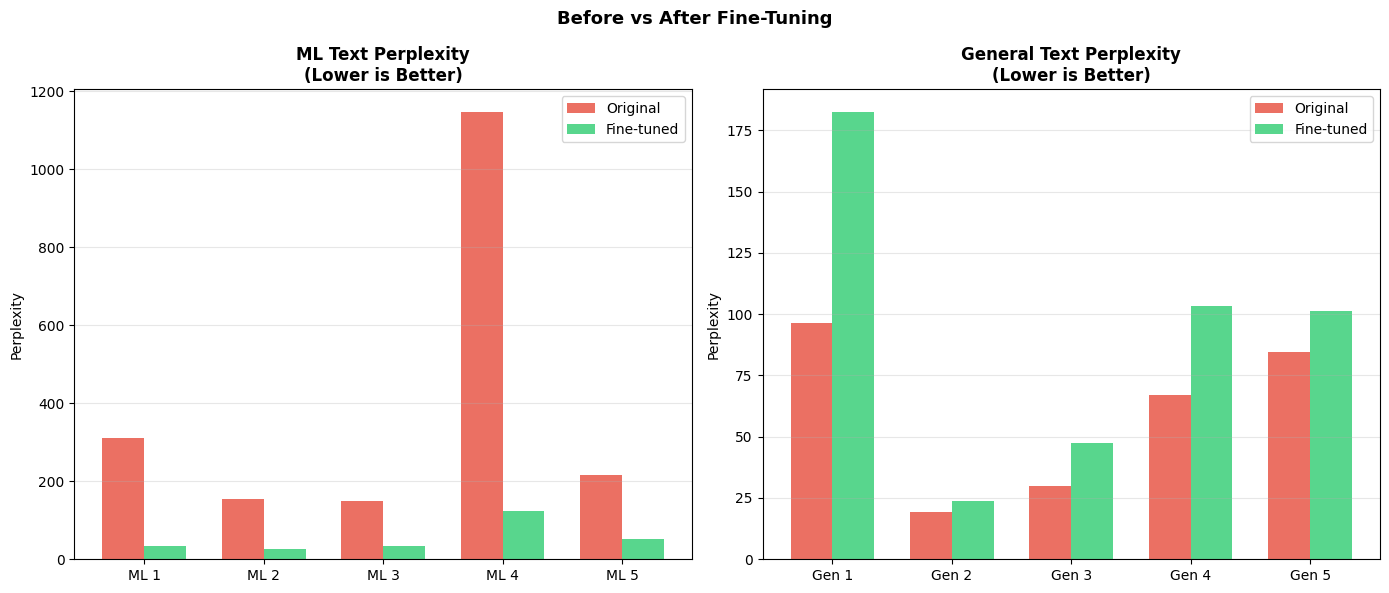

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — ML text perplexity
x = range(len(ml_texts))
width = 0.35
labels = [f"ML {i+1}" for i in range(len(ml_texts))]

axes[0].bar([i - width/2 for i in x], orig_ml, width, label="Original", color="#e74c3c", alpha=0.8)
axes[0].bar([i + width/2 for i in x], ft_ml, width, label="Fine-tuned", color="#2ecc71", alpha=0.8)
axes[0].set_title("ML Text Perplexity\n(Lower is Better)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Perplexity")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# Chart 2 — General text perplexity
x2 = range(len(general_texts))
labels2 = [f"Gen {i+1}" for i in range(len(general_texts))]

axes[1].bar([i - width/2 for i in x2], orig_gen, width, label="Original", color="#e74c3c", alpha=0.8)
axes[1].bar([i + width/2 for i in x2], ft_gen, width, label="Fine-tuned", color="#2ecc71", alpha=0.8)
axes[1].set_title("General Text Perplexity\n(Lower is Better)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Perplexity")
axes[1].set_xticks(list(x2))
axes[1].set_xticklabels(labels2)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("Before vs After Fine-Tuning", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("perplexity_comparison.png", dpi=300)
plt.show()

## 4. Text Generation Comparison

In [10]:
def generate_text(model, prompt: str, max_new_tokens: int = 80) -> str:
    """Generate text from a prompt."""
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model.generate(
            inputs.input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.8,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)


prompts = [
    "The transformer architecture uses attention to",
    "Fine-tuning a language model means",
    "FAISS is a library for",
]

print("=== GENERATION COMPARISON ===\n ")
for prompt in prompts:
    print(f"Prompt: {prompt}")
    print(f"nOriginal: {generate_text(original_model, prompt)[:200]}")
    print(f"\nFine-tuned: {generate_text(finetuned_model, prompt)[:200]}")
    print("\n" + "="*60 + "\n")

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


=== GENERATION COMPARISON ===
 
Prompt: The transformer architecture uses attention to
nOriginal: The transformer architecture uses attention to detail in a way that is consistent with the design and performance of the transformer. In this way, a transformer is less efficient than a transformer.



Fine-tuned: The transformer architecture uses attention to predict the input frequency of the transformers.


Prompt: Fine-tuning a language model means
nOriginal: Fine-tuning a language model means you can build a library that can use the correct language to use it. The best way to improve this is by making it more readable, easier to use, and easier to use.




Fine-tuned: Fine-tuning a language model means that the language model generates a sentence from both the given language and the other language.


Prompt: FAISS is a library for
nOriginal: FAISS is a library for the community to help people with disabilities understand and understand their disabilities. The Library for the Arts is a

## 5. Key Observations

| Metric | Before | After | Change |
|--------|--------|-------|--------|
| ML text perplexity | 395.9 | 54.2 | -86% |
| General text perplexity | 59.4 | 91.6 | +54% |

## Generation Quality
- Original: "transformer" → electrical transformer, building material
- Fine-tuned: "transformer" → attention mechanism, ML context

## Catastrophic Forgetting
Fine-tuning on 41 ML sentences caused the model to partially forget general language.
General text perplexity increased by 54%.

This is a known problem in fine-tuning — the model overwrites general knowledge.

## Solutions
- More training data — dilute the domain-specific signal
- Lower learning rate — smaller weight updates preserve more general knowledge
- Fewer epochs — stop before the model forgets too much
- Mixed training — combine domain text with general text

## Conclusion
Fine-tuning works — ML perplexity dropped 86%.
But small datasets cause catastrophic forgetting.
In production, use thousands of domain examples, not 41.